In [1]:
import os
import numpy as np

# ============================================================
# SETTINGS
# ============================================================

C_DIR = "Cpca_outputs"
P_DIR = "Ppca_outputs"

LMAX = 5000
D = LMAX - 1

FIELDS = ["TT", "EE", "BB", "RHO"]

# ============================================================
# HELPERS
# ============================================================

def read_info(path):

    info = {}

    with open(path, "r") as f:

        for line in f:

            k, v = line.strip().split()

            try:
                info[k] = int(v)
            except:
                info[k] = float(v)

    return info


def load_shape(path, dtype=np.float64):

    nbytes = os.path.getsize(path)

    return nbytes // np.dtype(dtype).itemsize


def print_cmp(name, cval, pval):

    status = "MATCH"

    if cval != pval:
        status = "DIFF"

    print(
        f"{name:30s} "
        f"C = {str(cval):20s} "
        f"P = {str(pval):20s} "
        f"{status}"
    )


# ============================================================
# GLOBAL FILES
# ============================================================

print("\n================================================")
print("GLOBAL FILE COMPARISON")
print("================================================")

global_files = [
    ("params_4999.bin", np.float64),
    ("ells_4999.bin", np.int64),
]

for fname, dtype in global_files:

    cpath = f"{C_DIR}/{fname}"
    ppath = f"{P_DIR}/{fname}"

    csize = load_shape(cpath, dtype=dtype)
    psize = load_shape(ppath, dtype=dtype)

    print_cmp(fname, csize, psize)

# ============================================================
# PCA FILES
# ============================================================

for q in FIELDS:

    print("\n================================================")
    print(f"{q} COMPARISON")
    print("================================================")

    cinfo = read_info(
        f"{C_DIR}/{q}_info.txt"
    )

    pinfo = read_info(
        f"{P_DIR}/{q}_info.txt"
    )

    # --------------------------------------------------------
    # INFO FILE VALUES
    # --------------------------------------------------------

    print("\nINFO VALUES\n")

    keys = [
        "Ntrain",
        "Ntest",
        "D",
        "modes",
        "variance_cut",
        "variance_loss",
        "explained_variance",
        "mse_train",
        "mse_test"
    ]

    for k in keys:

        print_cmp(
            k,
            cinfo[k],
            pinfo[k]
        )

    # --------------------------------------------------------
    # EXPECTED SHAPES
    # --------------------------------------------------------

    ntrain = int(cinfo["Ntrain"])
    ntest  = int(cinfo["Ntest"])

    d = int(cinfo["D"])

    cmodes = int(cinfo["modes"])
    pmodes = int(pinfo["modes"])

    print("\nARRAY SHAPES\n")

    file_specs = [

        (
            f"{q}_train_transformed.bin",
            (ntrain, d),
            (ntrain, d)
        ),

        (
            f"{q}_test_transformed.bin",
            (ntest, d),
            (ntest, d)
        ),

        (
            f"{q}_mean.bin",
            (d,),
            (d,)
        ),

        (
            f"{q}_singular.bin",
            (cmodes,),
            (pmodes,)
        ),

        (
            f"{q}_basis.bin",
            (d, cmodes),
            (d, pmodes)
        ),

        (
            f"{q}_coeff_train.bin",
            (ntrain, cmodes),
            (ntrain, pmodes)
        ),

        (
            f"{q}_coeff_test.bin",
            (ntest, cmodes),
            (ntest, pmodes)
        ),

        (
            f"{q}_recon_train.bin",
            (ntrain, d),
            (ntrain, d)
        ),

        (
            f"{q}_recon_test.bin",
            (ntest, d),
            (ntest, d)
        ),
    ]

    for fname, cshape, pshape in file_specs:

        cpath = f"{C_DIR}/{fname}"
        ppath = f"{P_DIR}/{fname}"

        csize = load_shape(cpath)
        psize = load_shape(ppath)

        cexpected = np.prod(cshape)
        pexpected = np.prod(pshape)

        print_cmp(
            fname,
            f"{cshape} [{csize}]",
            f"{pshape} [{psize}]"
        )

        if csize != cexpected:
            print(
                f"  ERROR: C size mismatch "
                f"expected {cexpected} got {csize}"
            )

        if psize != pexpected:
            print(
                f"  ERROR: P size mismatch "
                f"expected {pexpected} got {psize}"
            )

print("\n================================================")
print("DONE")
print("================================================")


GLOBAL FILE COMPARISON
params_4999.bin                C = 16885                P = 16885                MATCH
ells_4999.bin                  C = 4999                 P = 4999                 MATCH

TT COMPARISON

INFO VALUES

Ntrain                         C = 200                  P = 200                  MATCH
Ntest                          C = 10                   P = 10                   MATCH
D                              C = 4999                 P = 4999                 MATCH
modes                          C = 7                    P = 7                    MATCH
variance_cut                   C = 0.995                P = 0.995                MATCH
variance_loss                  C = 0.004784895699909308 P = 0.004784895699909142 DIFF
explained_variance             C = 0.9952151043000907   P = 0.9952151043000909   DIFF
mse_train                      C = 1.567749873512844e-09 P = 1.567749873512906e-09 DIFF
mse_test                       C = 1.310786210609373e-09 P = 1.310786210609811


COMPARING TT
Modes: 7
Flipped modes: [1]

COMPARING EE
Modes: 7
Flipped modes: [0, 3, 4, 5]

COMPARING BB
Modes: 4
Flipped modes: [0, 1, 2, 3]


/home/shambhavij.sps.iitmandi/.local/lib/python3.7/site-packages/ipykernel_launcher.py:230: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).



COMPARING RHO
Modes: 10
Flipped modes: [0, 1, 2, 5, 6, 8, 9]


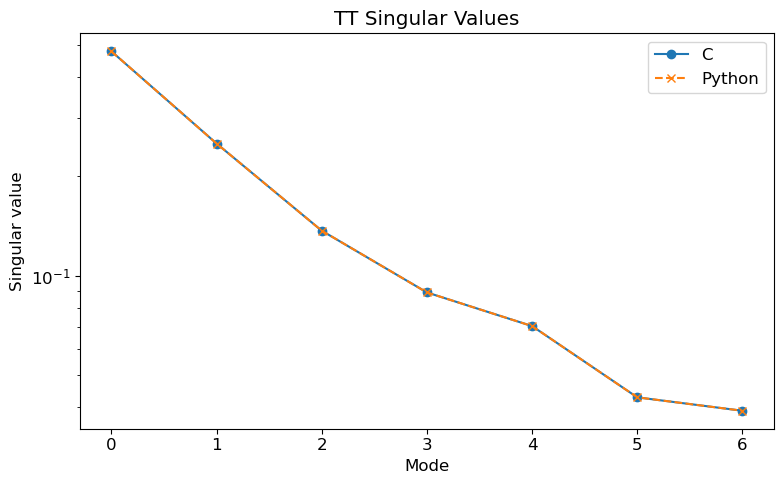

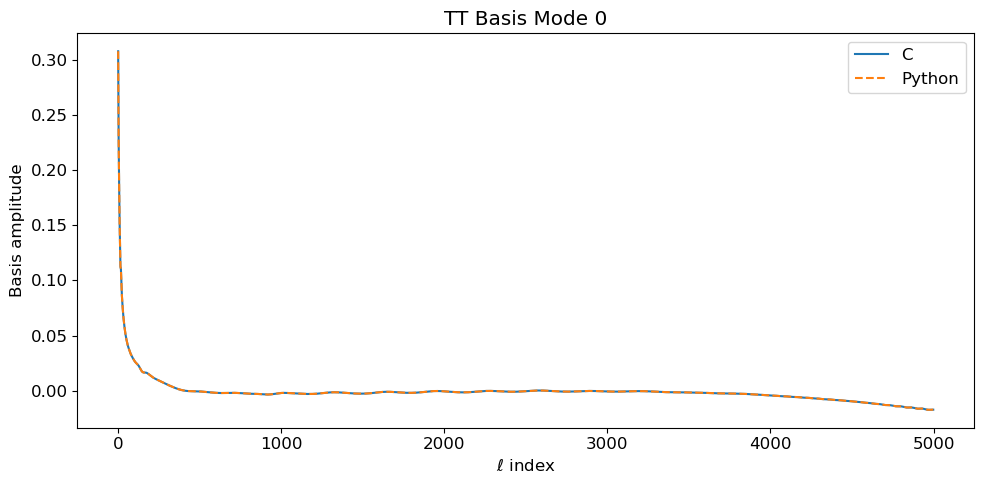

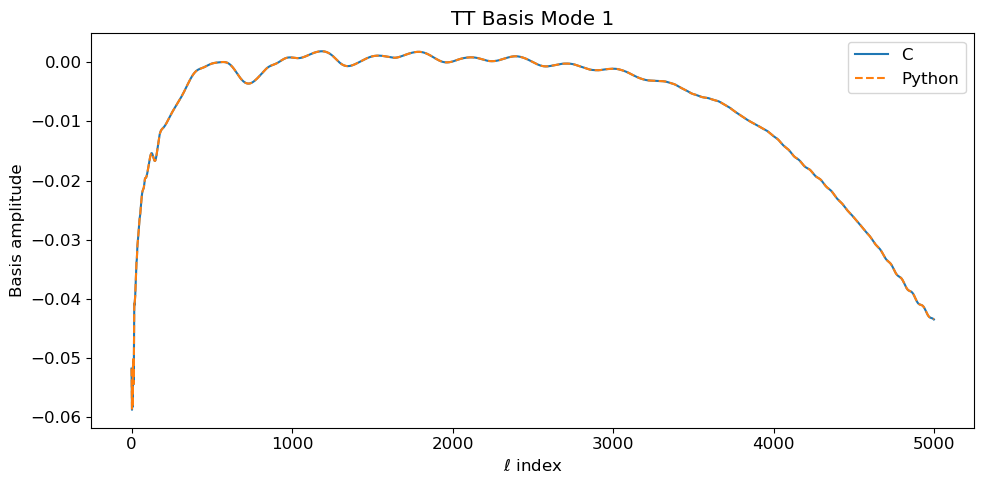

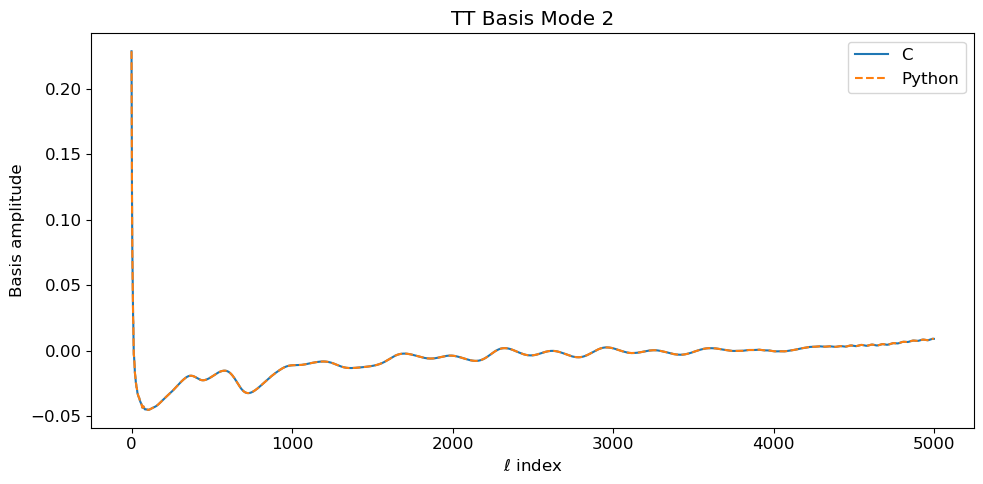

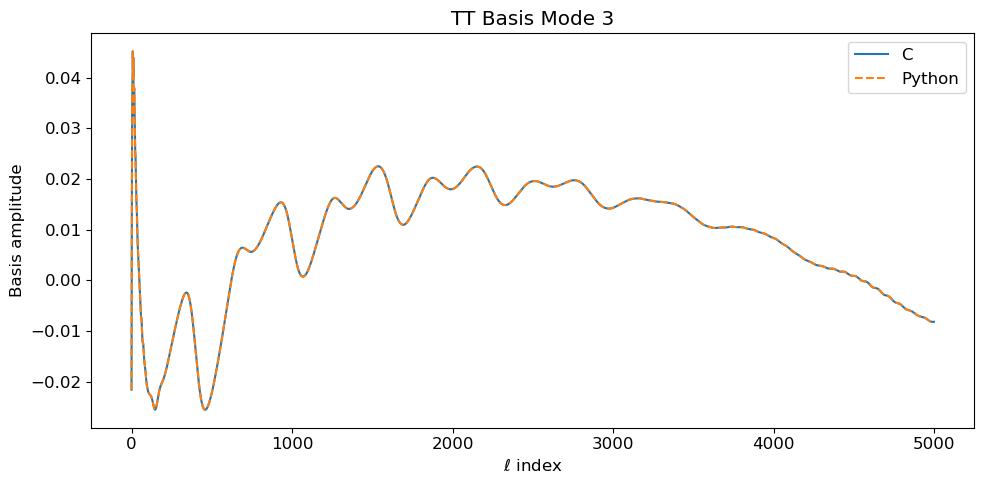

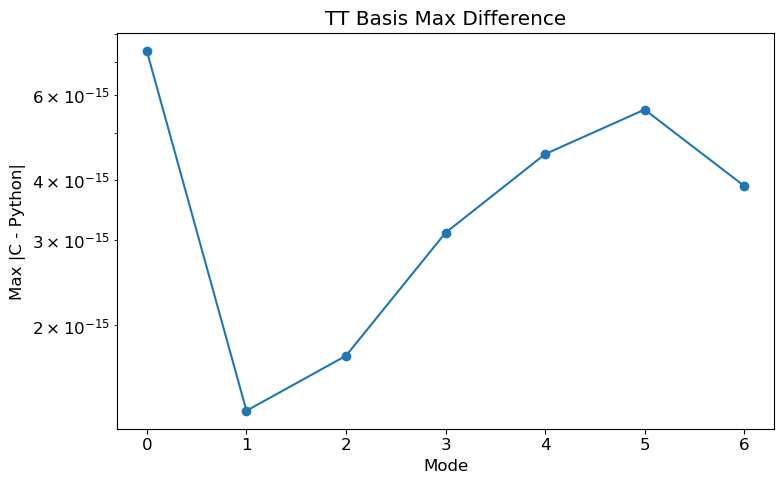

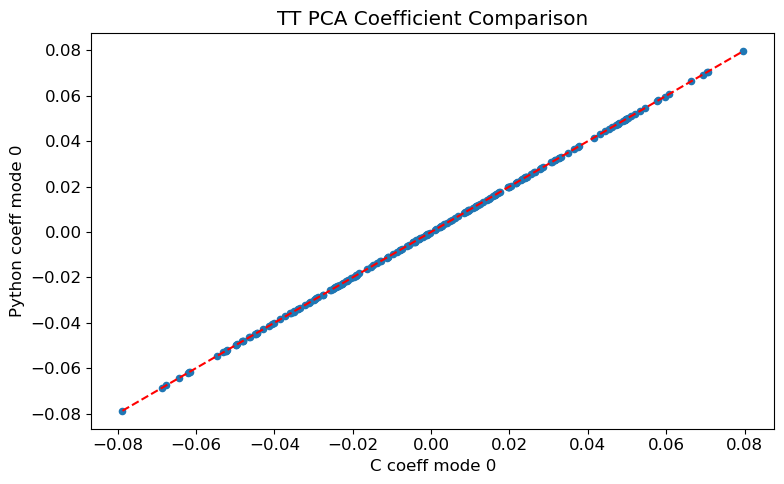

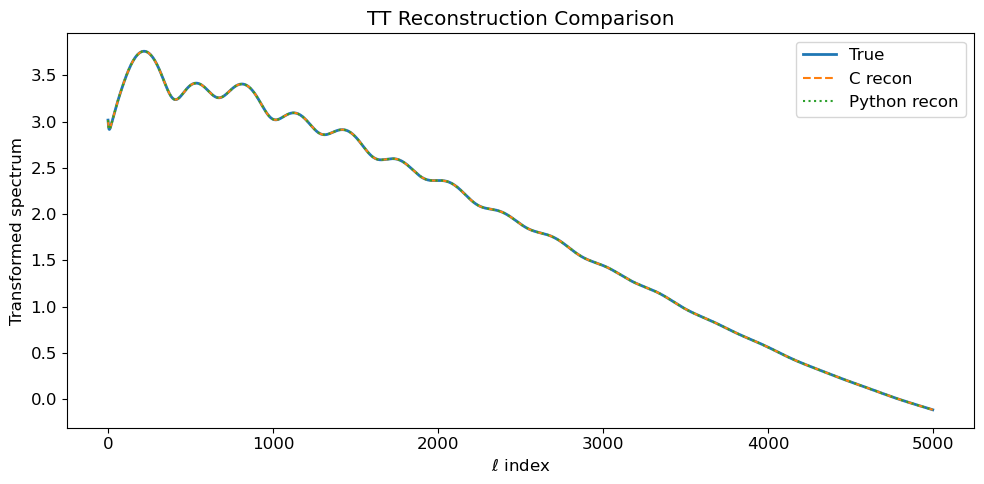

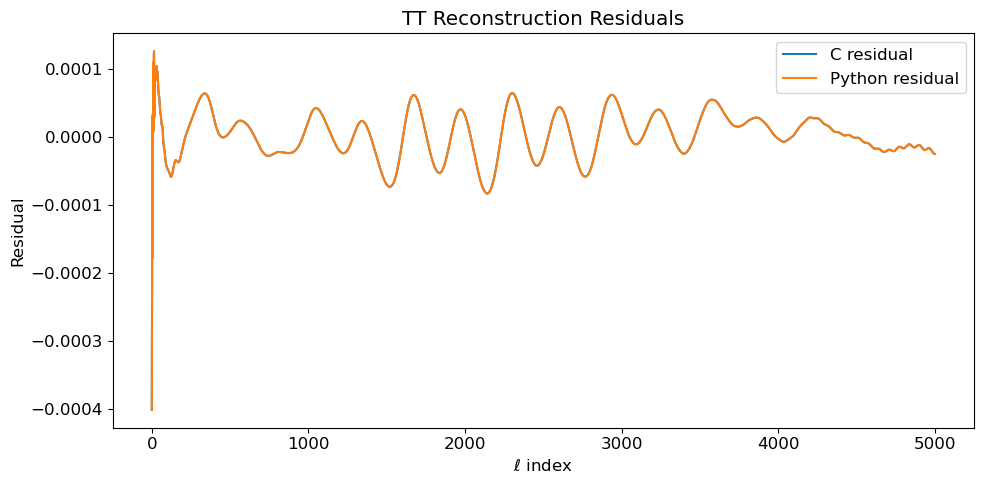

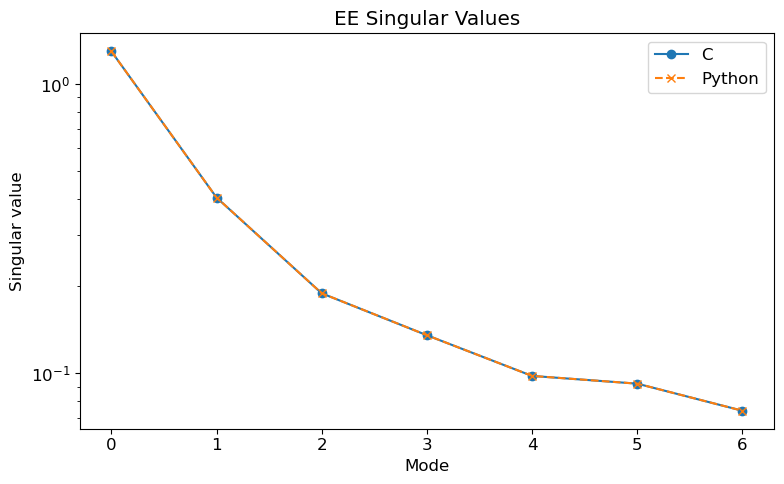

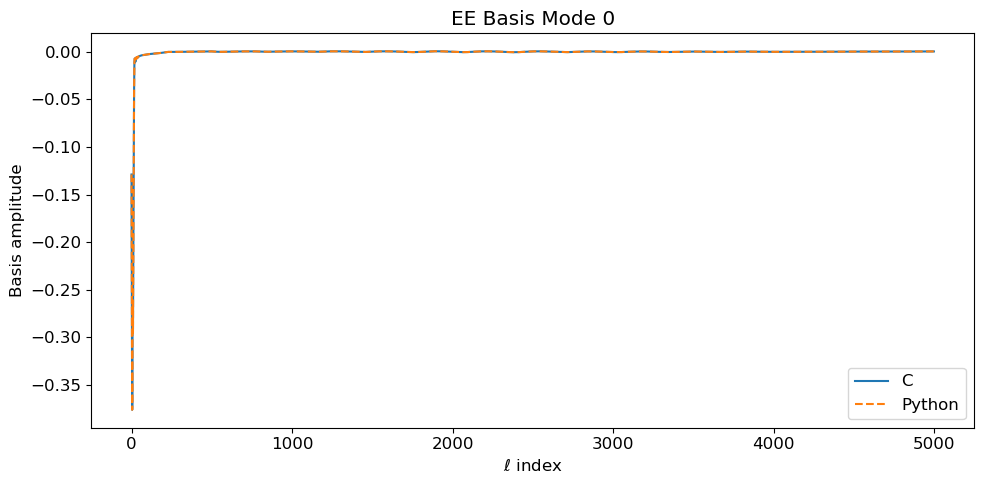

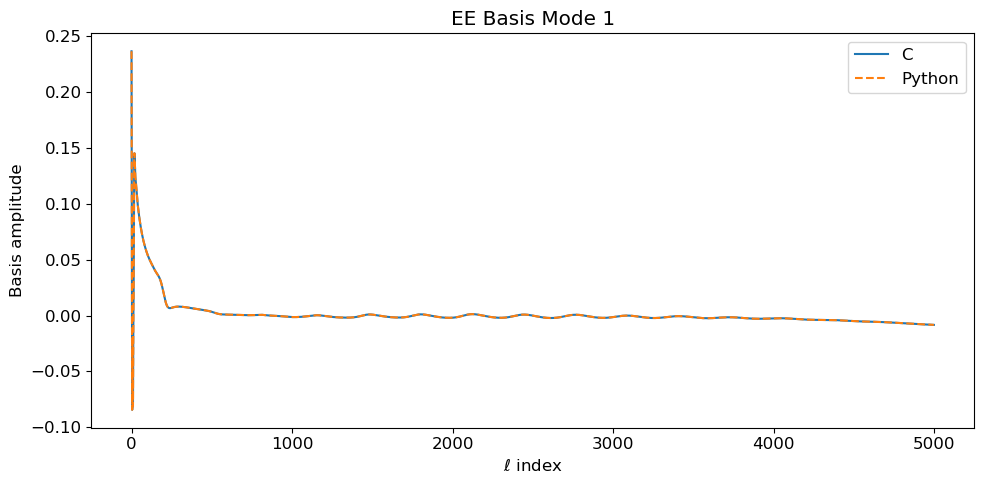

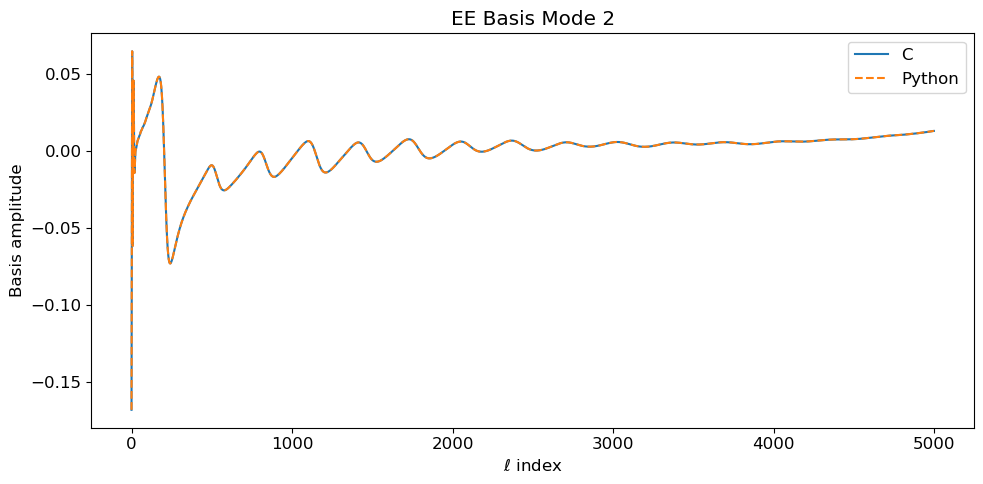

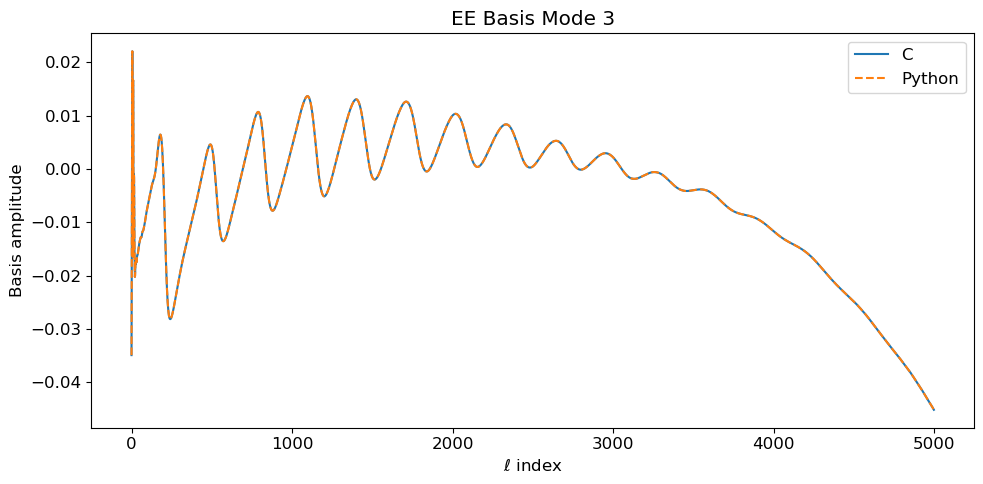

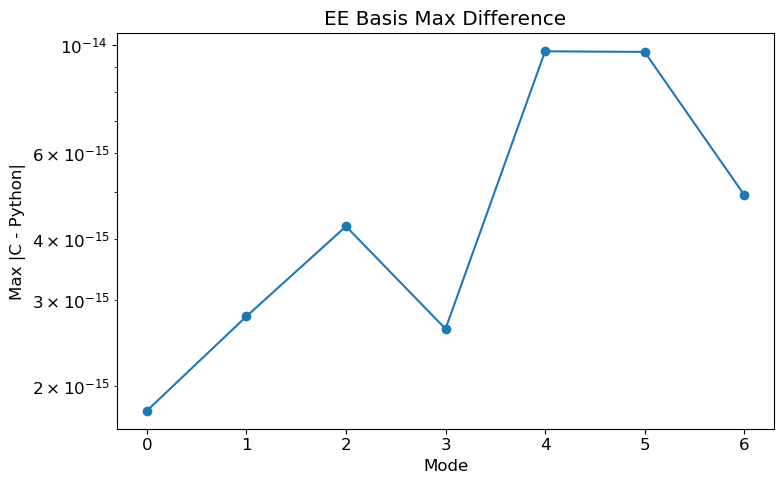

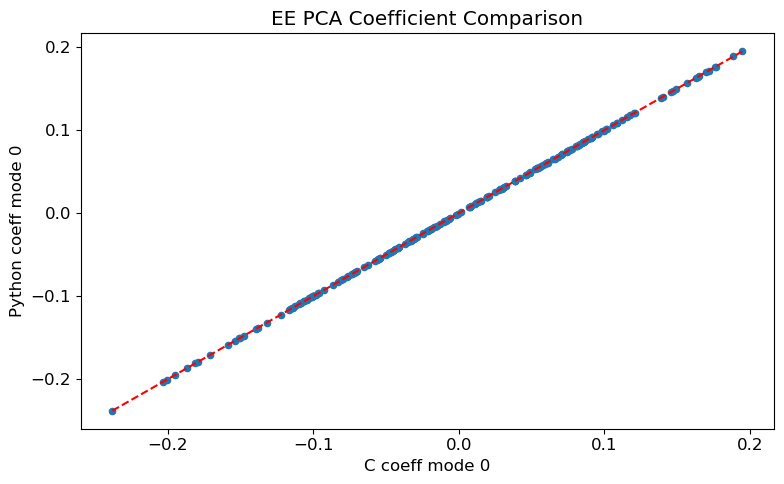

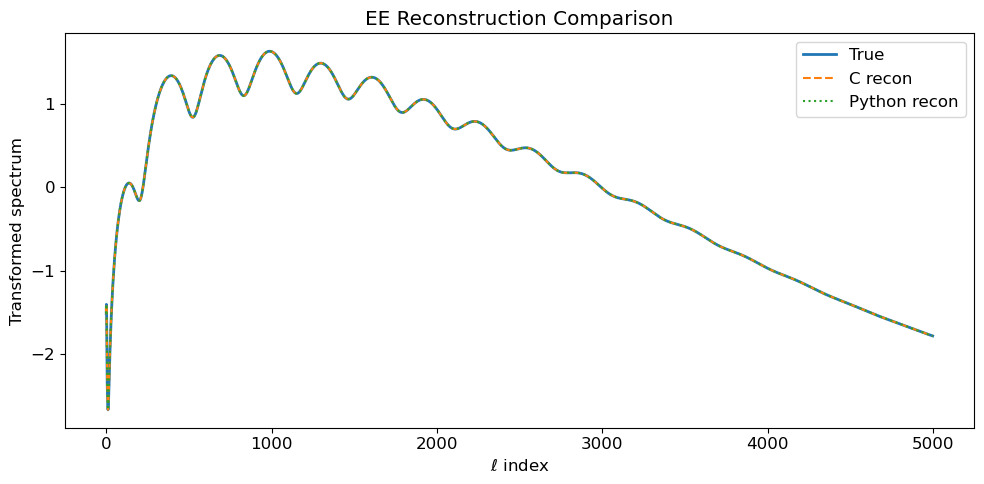

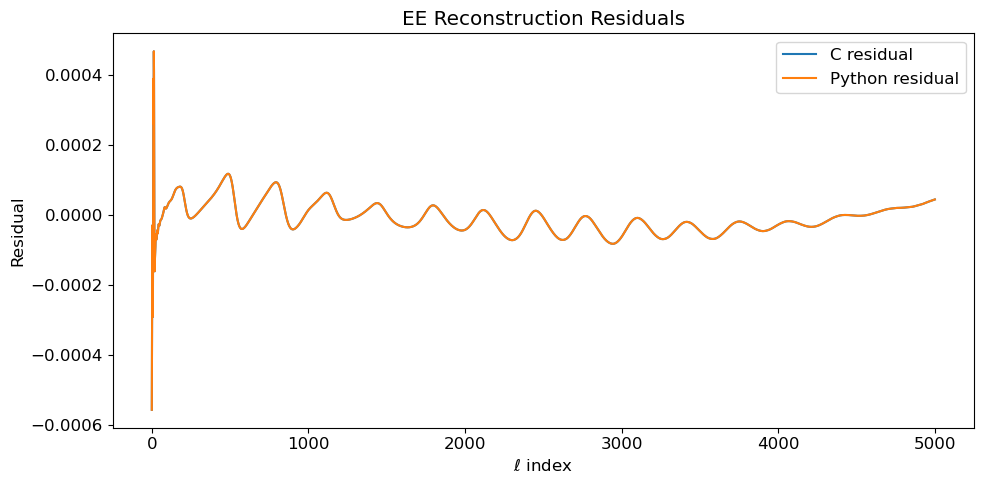

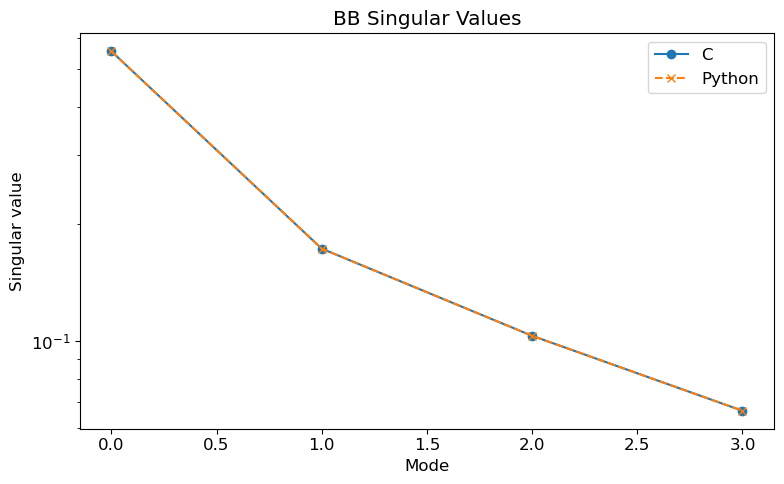

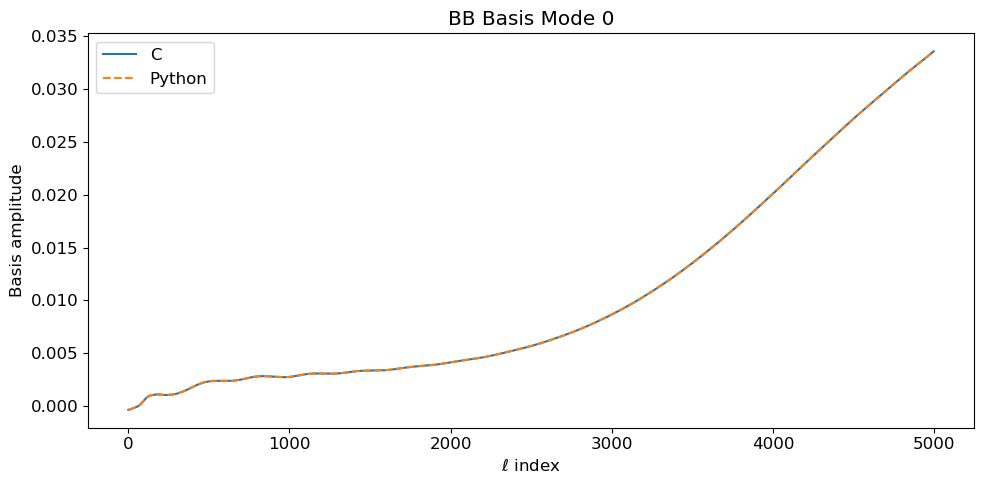

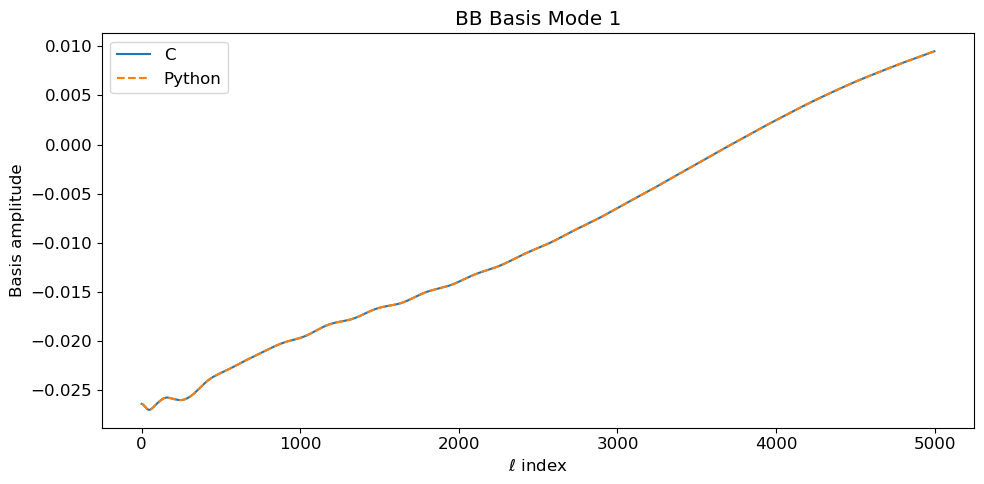

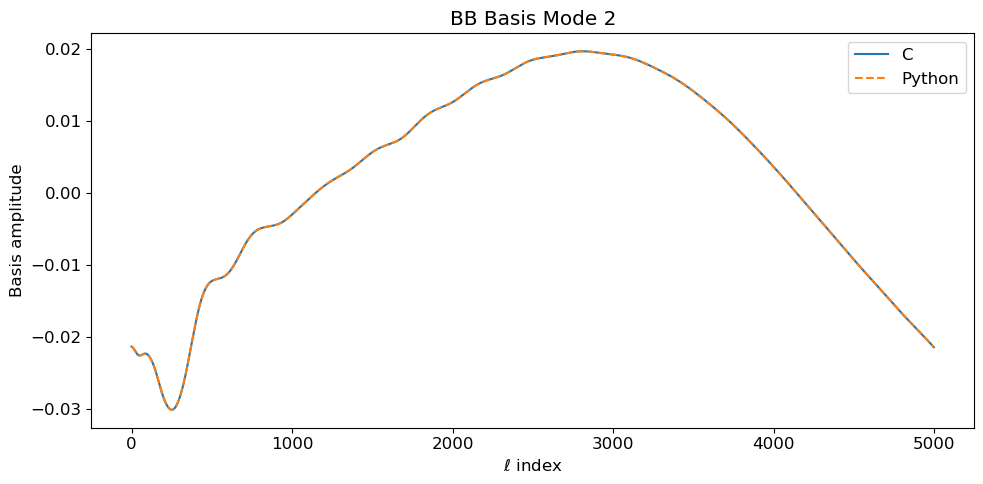

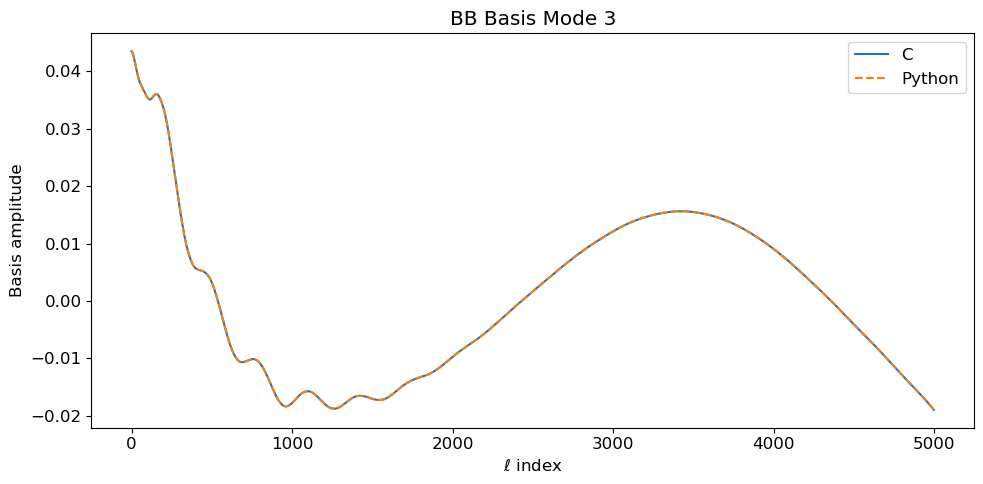

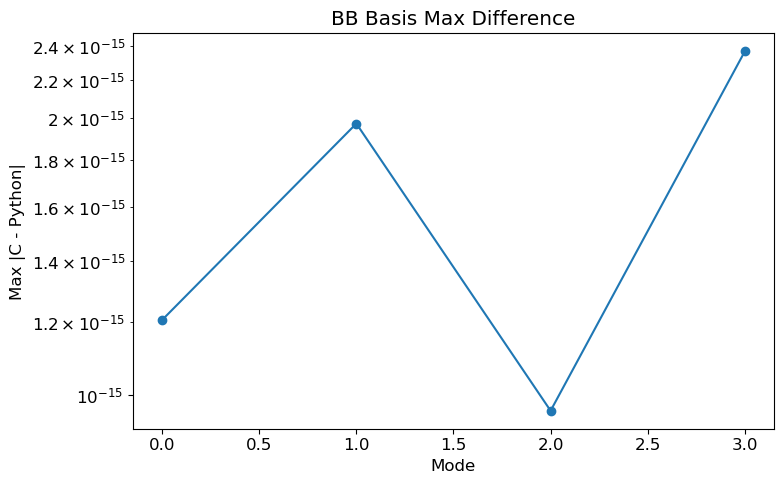

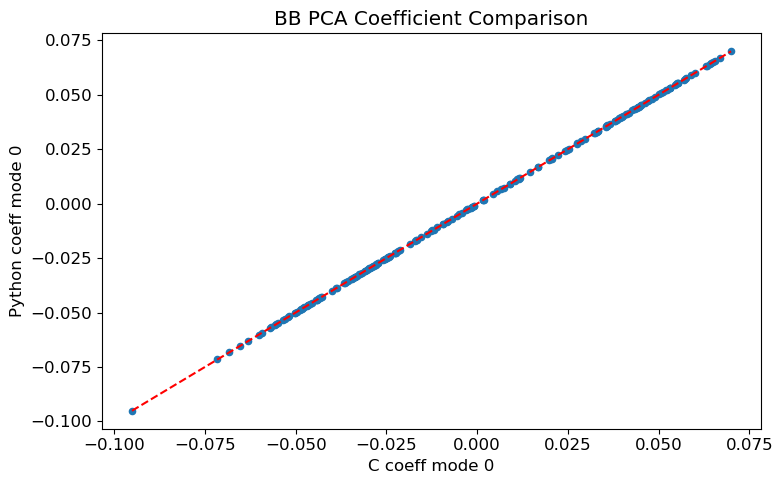

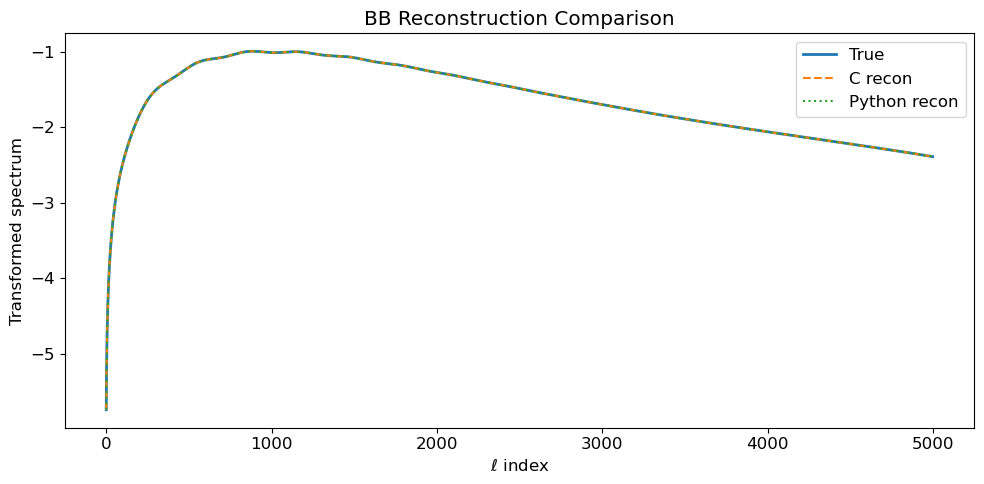

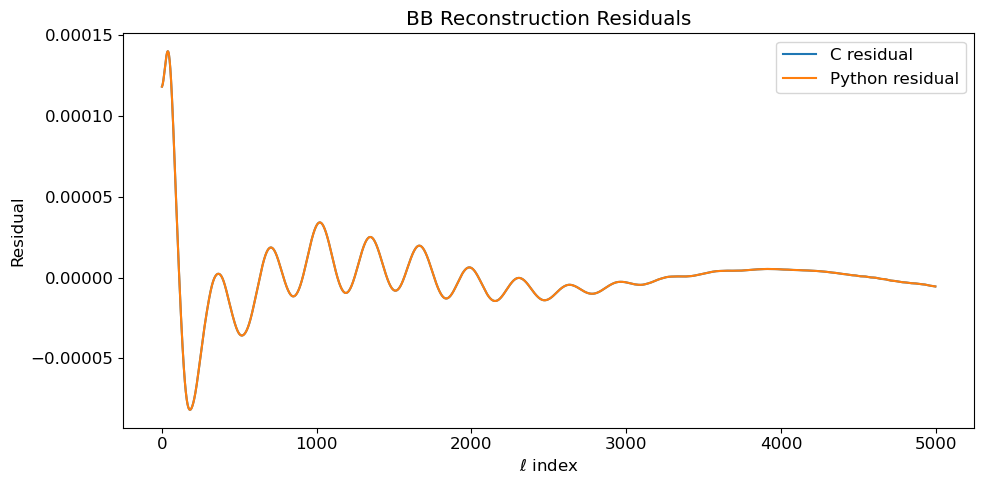

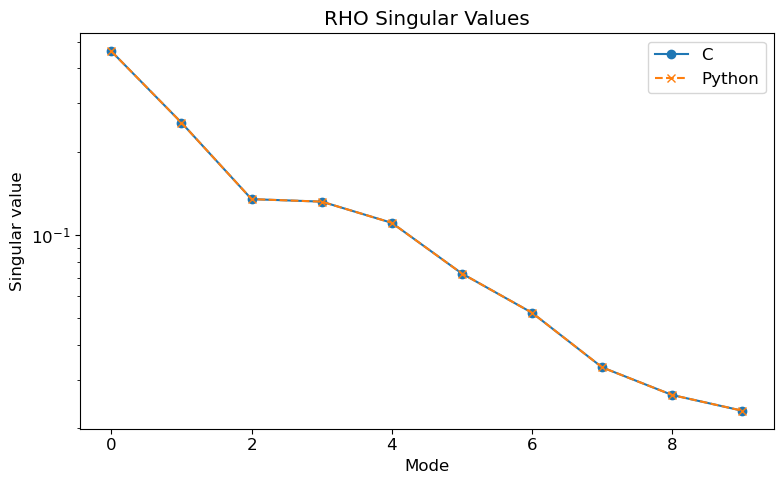

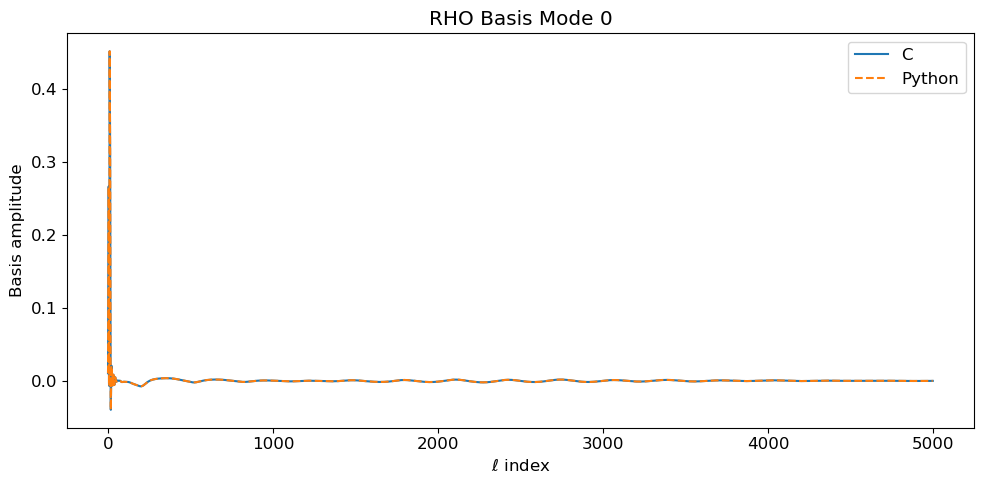

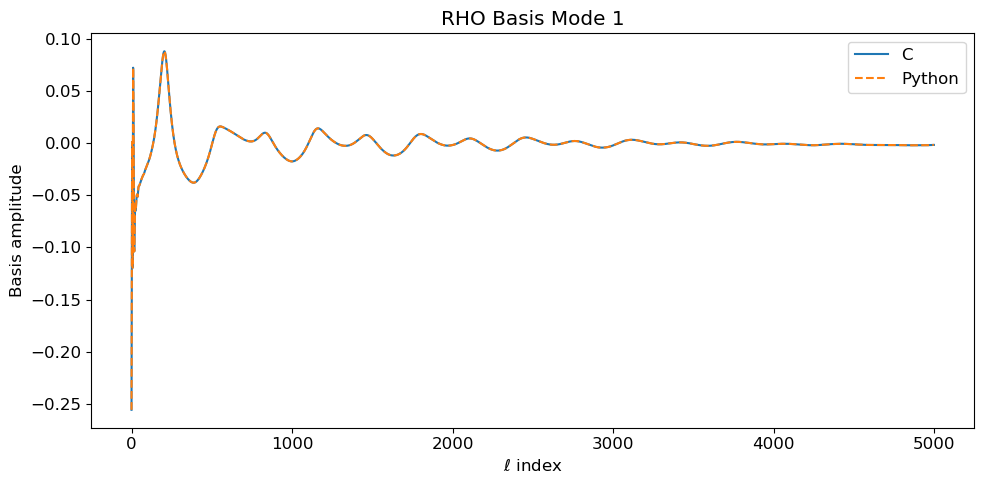

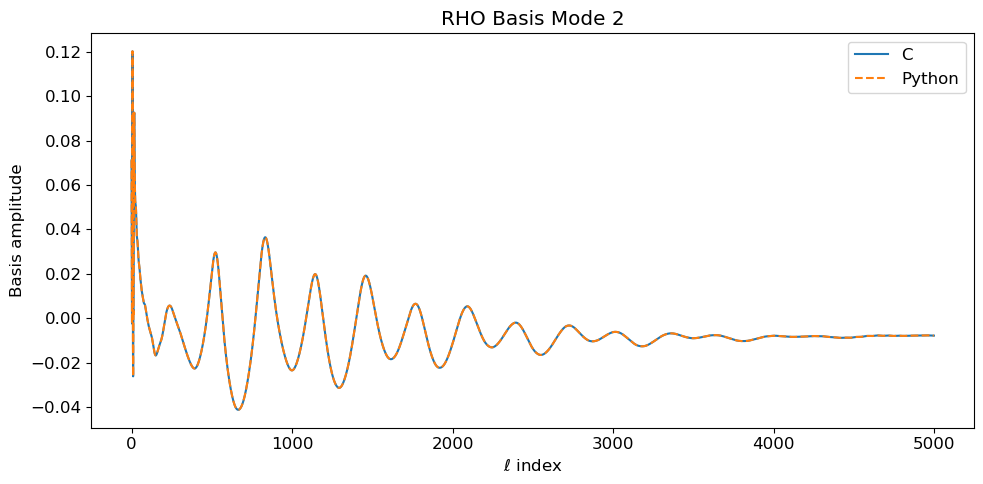

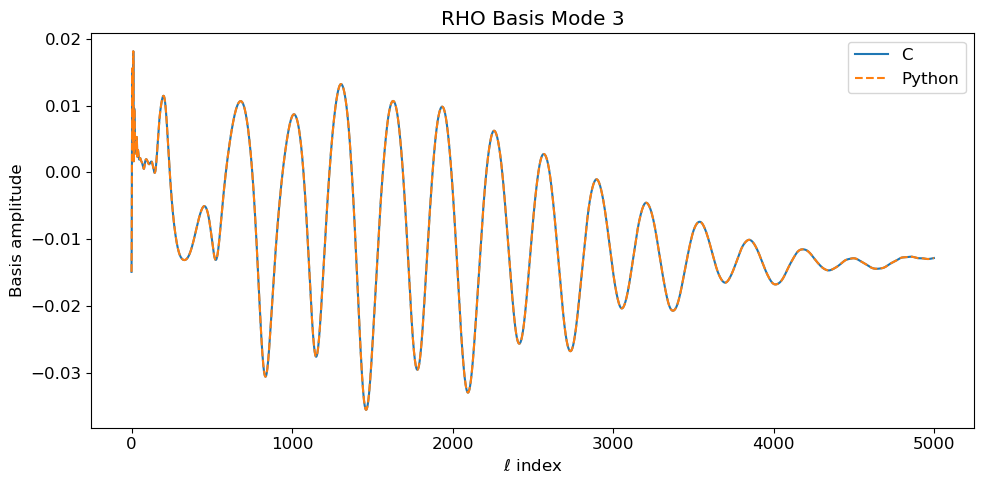

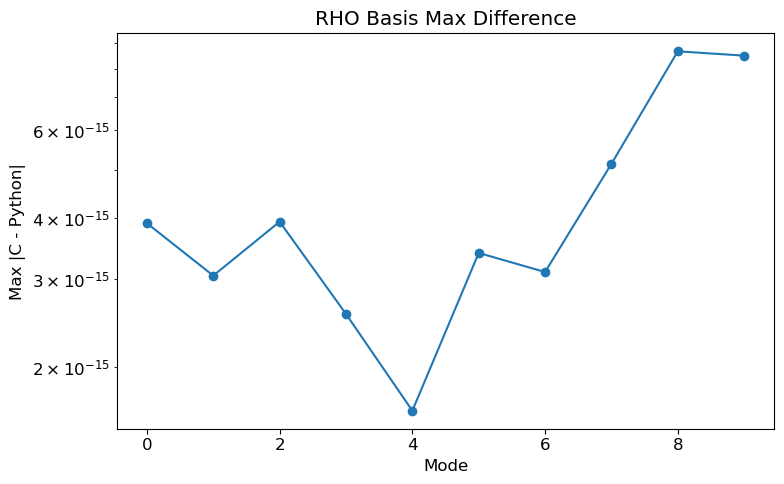

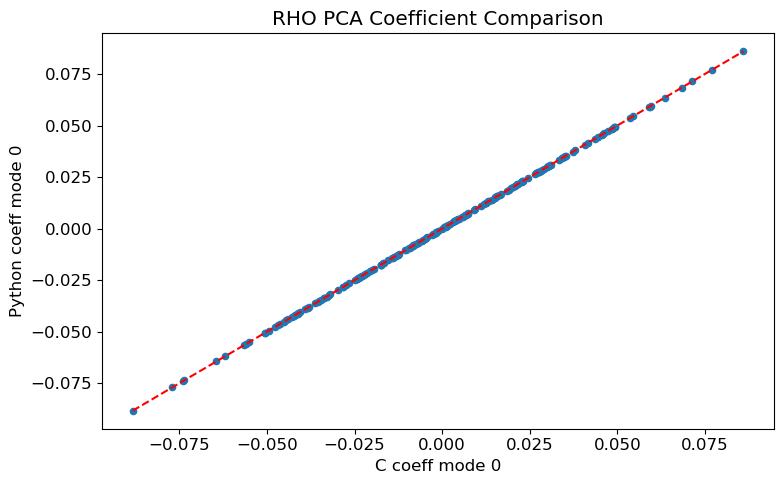

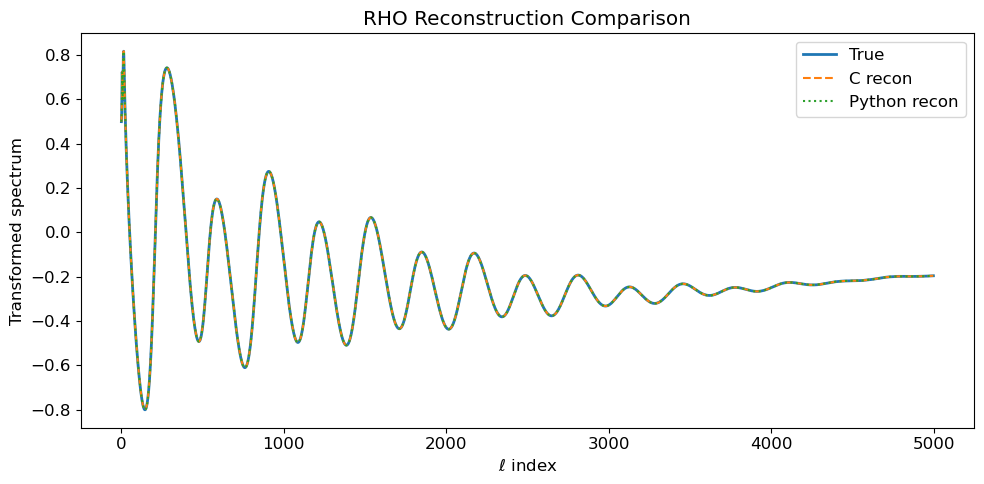

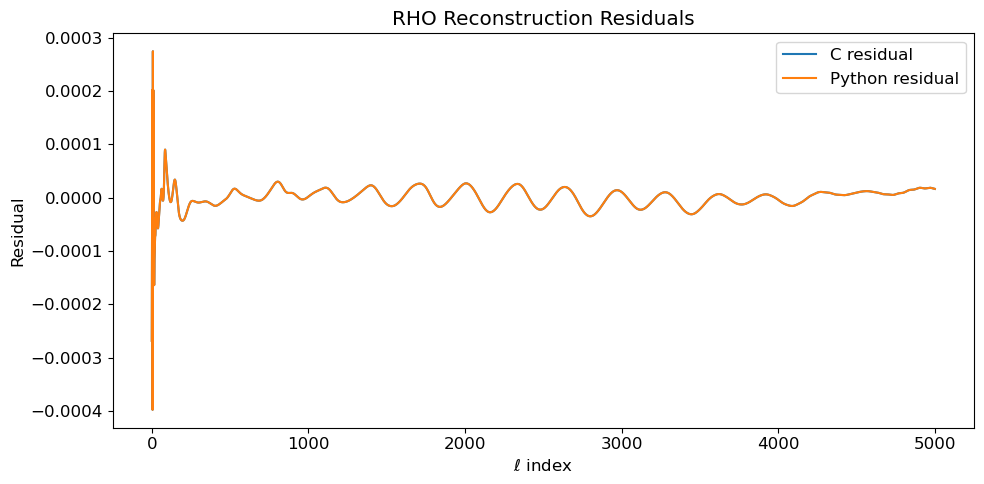

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# SETTINGS
# ============================================================

C_DIR = "Cpca_outputs"
P_DIR = "Ppca_outputs"

D = 4999

FIELDS = ["TT", "EE", "BB", "RHO"]

# ============================================================
# HELPERS
# ============================================================

def read_info(fname):

    info = {}

    with open(fname, "r") as f:

        for line in f:

            parts = line.strip().split()

            if len(parts) != 2:
                continue

            k, v = parts

            try:
                info[k] = int(v)
            except ValueError:
                info[k] = float(v)

    return info


def load_array(fname, shape=None, dtype=np.float64):

    arr = np.fromfile(fname, dtype=dtype)

    if shape is not None:

        shape = list(shape)

        # allow -1 inference
        if -1 in shape:

            neg_index = shape.index(-1)

            known = 1

            for s in shape:
                if s != -1:
                    known *= s

            shape[neg_index] = arr.size // known

        arr = arr.reshape(shape)

    return arr


def align_signs(basis_ref, basis_target,
                coeff_ref=None, coeff_target=None):

    """
    Align PCA mode signs using dot products.
    """

    basis_target = basis_target.copy()

    if coeff_target is not None:
        coeff_target = coeff_target.copy()

    nmodes = basis_ref.shape[1]

    flips = []

    for m in range(nmodes):

        dot = np.dot(
            basis_ref[:, m],
            basis_target[:, m]
        )

        if dot < 0:

            basis_target[:, m] *= -1

            if coeff_target is not None:
                coeff_target[:, m] *= -1

            flips.append(m)

    return basis_target, coeff_target, flips


# ============================================================
# GLOBAL STYLE
# ============================================================

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["font.size"] = 12

# ============================================================
# LOOP OVER SPECTRA
# ============================================================

for q in FIELDS:

    print("\n================================================")
    print(f"COMPARING {q}")
    print("================================================")

    # --------------------------------------------------------
    # LOAD INFO
    # --------------------------------------------------------

    info_c = read_info(f"{C_DIR}/{q}_info.txt")
    info_p = read_info(f"{P_DIR}/{q}_info.txt")

    nmodes = info_c["modes"]

    print("Modes:", nmodes)

    # --------------------------------------------------------
    # LOAD ARRAYS
    # --------------------------------------------------------

    sing_c = load_array(
        f"{C_DIR}/{q}_singular.bin"
    )

    sing_p = load_array(
        f"{P_DIR}/{q}_singular.bin"
    )

    basis_c = load_array(
        f"{C_DIR}/{q}_basis.bin",
        (D, nmodes)
    )

    basis_p = load_array(
        f"{P_DIR}/{q}_basis.bin",
        (D, nmodes)
    )

    coeff_c = load_array(
        f"{C_DIR}/{q}_coeff_train.bin",
        (-1, nmodes)
    )

    coeff_p = load_array(
        f"{P_DIR}/{q}_coeff_train.bin",
        (-1, nmodes)
    )

    recon_c = load_array(
        f"{C_DIR}/{q}_recon_test.bin",
        (-1, D)
    )

    recon_p = load_array(
        f"{P_DIR}/{q}_recon_test.bin",
        (-1, D)
    )

    true_spec = load_array(
        f"{C_DIR}/{q}_test_transformed.bin",
        (-1, D)
    )

    # ========================================================
    # SIGN ALIGNMENT
    # ========================================================

    basis_p, coeff_p, flips = align_signs(
        basis_c,
        basis_p,
        coeff_c,
        coeff_p
    )

    print("Flipped modes:", flips)

    # ========================================================
    # SINGULAR VALUE COMPARISON
    # ========================================================

    plt.figure()

    plt.plot(
        sing_c,
        marker='o',
        label='C'
    )

    plt.plot(
        sing_p,
        marker='x',
        linestyle='--',
        label='Python'
    )

    plt.yscale("log")

    plt.xlabel("Mode")
    plt.ylabel("Singular value")

    plt.title(f"{q} Singular Values")

    plt.legend()

    plt.tight_layout()

    # ========================================================
    # BASIS MODE COMPARISON
    # ========================================================

    nplot = min(4, nmodes)

    for m in range(nplot):

        plt.figure(figsize=(10, 5))

        plt.plot(
            basis_c[:, m],
            label='C'
        )

        plt.plot(
            basis_p[:, m],
            linestyle='--',
            label='Python'
        )

        plt.xlabel(r"$\ell$ index")
        plt.ylabel("Basis amplitude")

        plt.title(f"{q} Basis Mode {m}")

        plt.legend()

        plt.tight_layout()

    # ========================================================
    # BASIS DIFFERENCE
    # ========================================================

    plt.figure()

    diff = np.abs(basis_c - basis_p)

    plt.plot(
        diff.max(axis=0),
        marker='o'
    )

    plt.yscale("log")

    plt.xlabel("Mode")
    plt.ylabel("Max |C - Python|")

    plt.title(f"{q} Basis Max Difference")

    plt.tight_layout()

    # ========================================================
    # COEFFICIENT COMPARISON
    # ========================================================

    plt.figure()

    plt.scatter(
        coeff_c[:, 0],
        coeff_p[:, 0],
        s=20
    )

    xmin = min(coeff_c[:, 0].min(),
               coeff_p[:, 0].min())

    xmax = max(coeff_c[:, 0].max(),
               coeff_p[:, 0].max())

    plt.plot(
        [xmin, xmax],
        [xmin, xmax],
        'r--'
    )

    plt.xlabel("C coeff mode 0")
    plt.ylabel("Python coeff mode 0")

    plt.title(f"{q} PCA Coefficient Comparison")

    plt.tight_layout()

    # ========================================================
    # RECONSTRUCTION COMPARISON
    # ========================================================

    sample = 0

    plt.figure(figsize=(10, 5))

    plt.plot(
        true_spec[sample],
        label='True',
        linewidth=2
    )

    plt.plot(
        recon_c[sample],
        '--',
        label='C recon'
    )

    plt.plot(
        recon_p[sample],
        ':',
        label='Python recon'
    )

    plt.xlabel(r"$\ell$ index")
    plt.ylabel("Transformed spectrum")

    plt.title(f"{q} Reconstruction Comparison")

    plt.legend()

    plt.tight_layout()

    # ========================================================
    # RECONSTRUCTION RESIDUALS
    # ========================================================

    plt.figure(figsize=(10, 5))

    plt.plot(
        recon_c[sample] - true_spec[sample],
        label='C residual'
    )

    plt.plot(
        recon_p[sample] - true_spec[sample],
        label='Python residual'
    )

    plt.xlabel(r"$\ell$ index")
    plt.ylabel("Residual")

    plt.title(f"{q} Reconstruction Residuals")

    plt.legend()

    plt.tight_layout()

# ============================================================
# SHOW ALL
# ============================================================

plt.show()


COMPARE C vs PYTHON GP
Field : TT
Ntest : 10
Modes : 7

Max truth difference:
0.0

MODE 0

C vs Python prediction difference
MAE     = 5.963167e-05
RMSE    = 7.380530e-05
MAX ERR = 1.746829e-04

MODE 1

C vs Python prediction difference
MAE     = 5.228402e-03
RMSE    = 7.236723e-03
MAX ERR = 1.877250e-02

MODE 2

C vs Python prediction difference
MAE     = 1.404691e-04
RMSE    = 1.754591e-04
MAX ERR = 3.735378e-04

MODE 3

C vs Python prediction difference
MAE     = 3.249454e-03
RMSE    = 5.603936e-03
MAX ERR = 1.575712e-02

MODE 4

C vs Python prediction difference
MAE     = 3.395978e-04
RMSE    = 3.980073e-04
MAX ERR = 6.365629e-04

MODE 5

C vs Python prediction difference
MAE     = 1.733491e-04
RMSE    = 2.391236e-04
MAX ERR = 5.763398e-04


/home/shambhavij.sps.iitmandi/.local/lib/python3.7/site-packages/ipykernel_launcher.py:203: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).



MODE 6

C vs Python prediction difference
MAE     = 8.061211e-04
RMSE    = 1.008813e-03
MAX ERR = 1.993943e-03

GLOBAL DIFFERENCES
Mean abs diff : 0.0014281464178595668
RMSE diff     : 0.003485557419835812
Max diff      : 0.01877249696151689


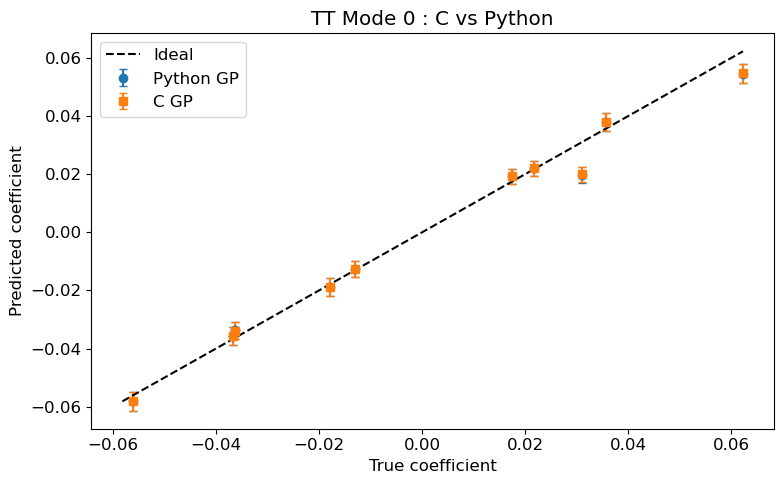

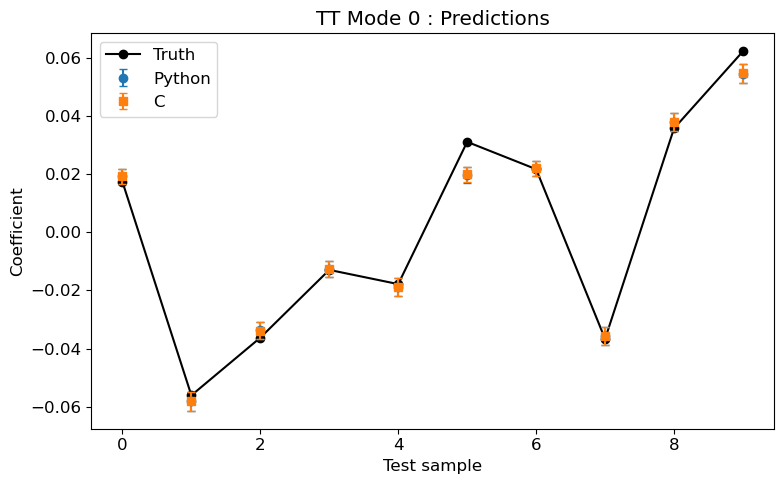

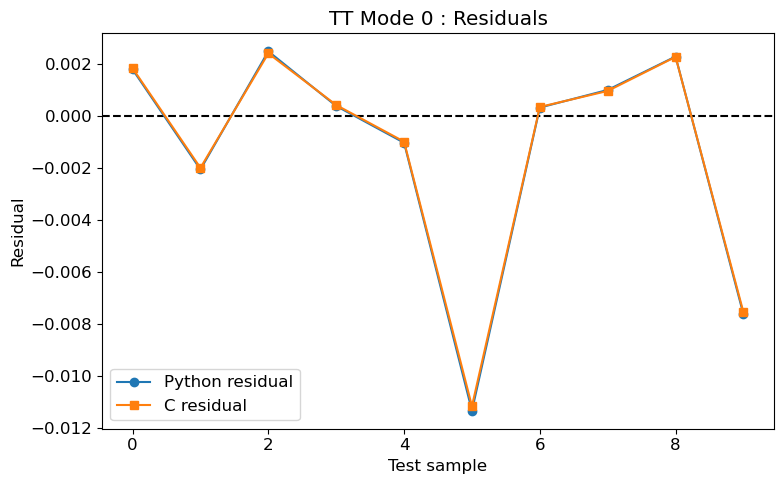

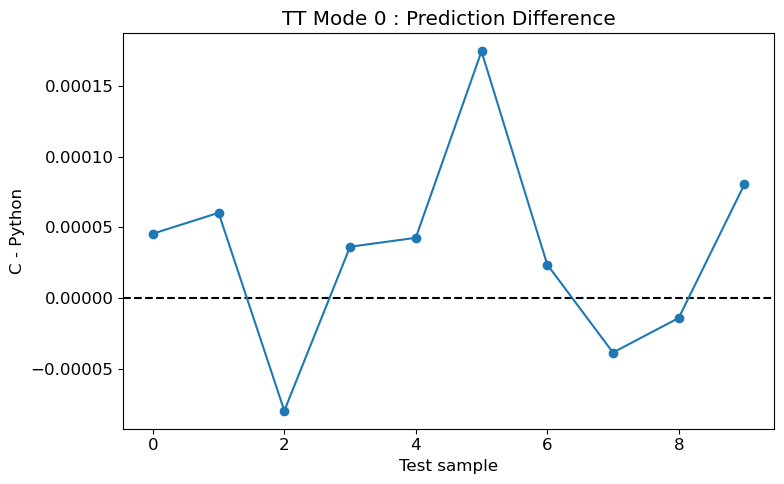

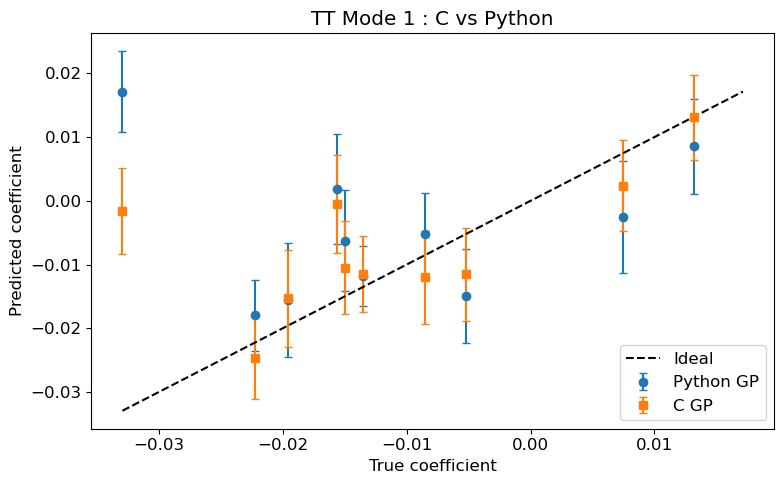

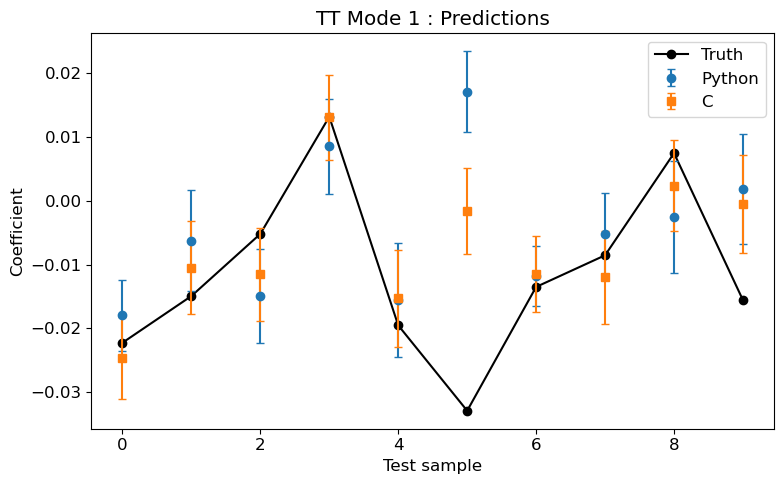

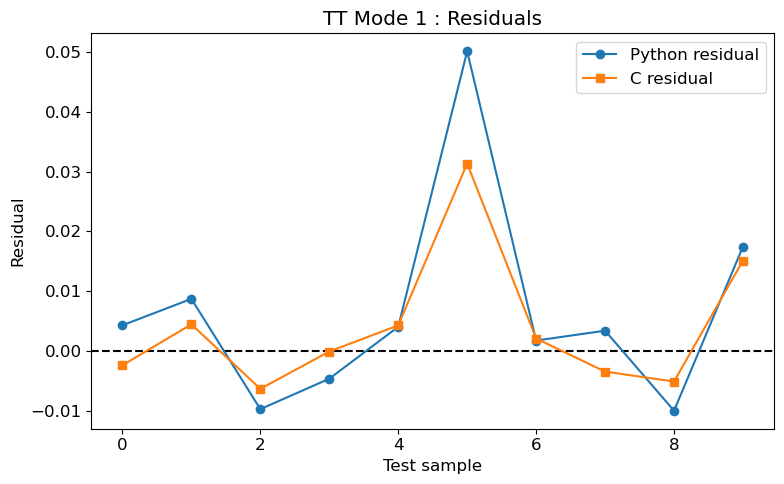

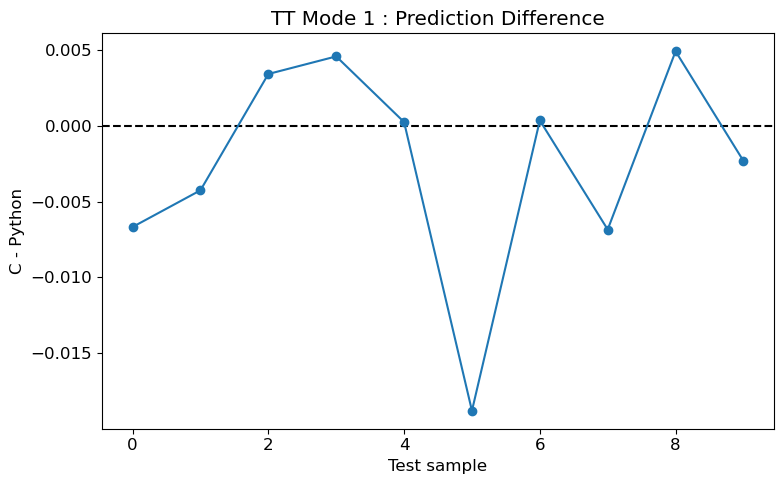

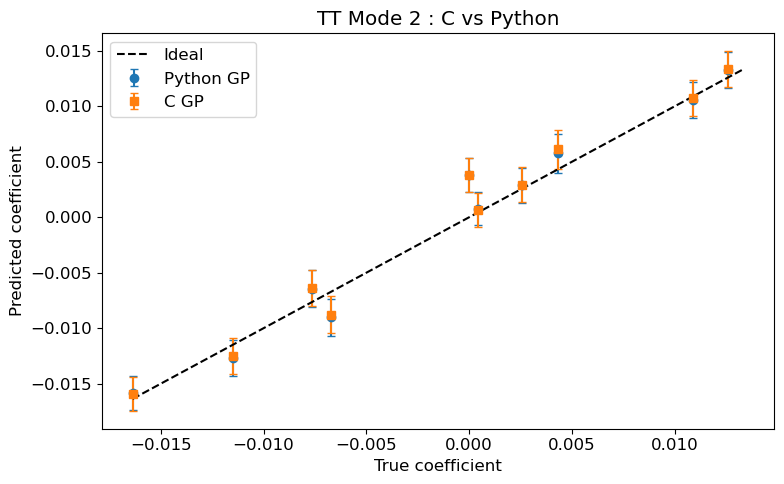

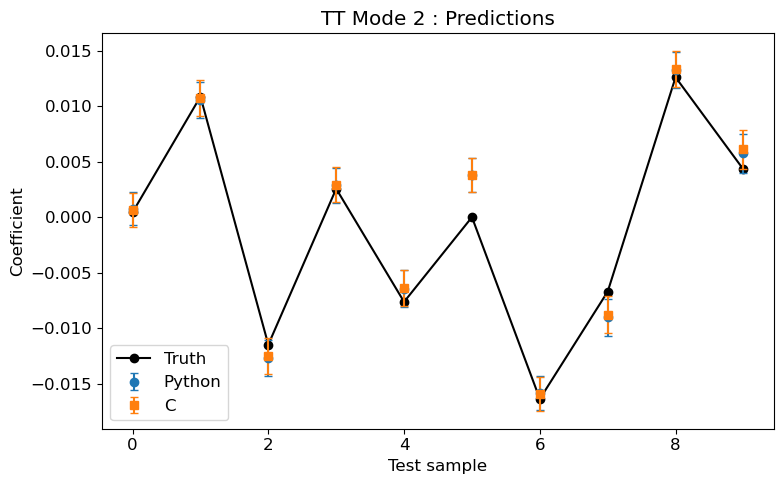

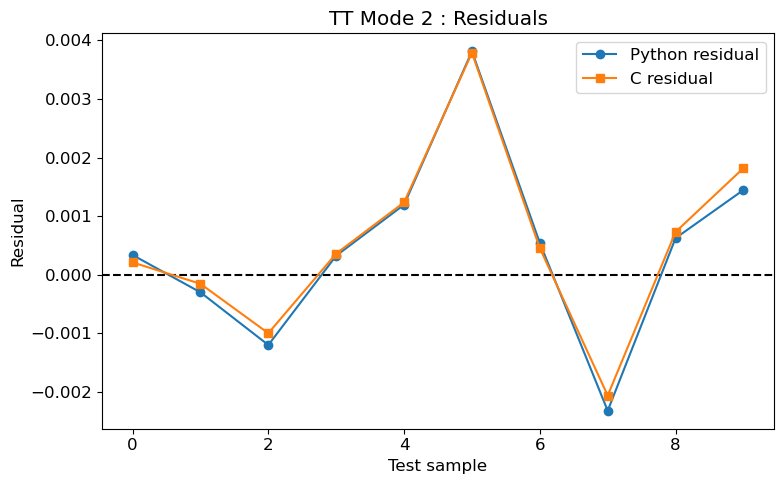

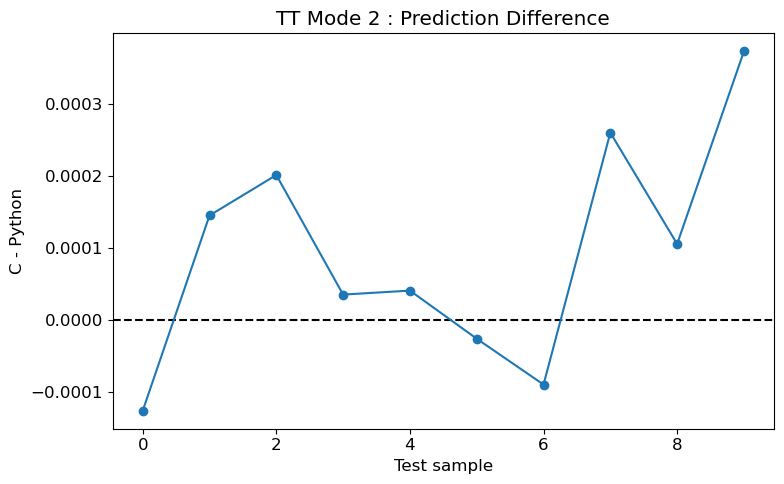

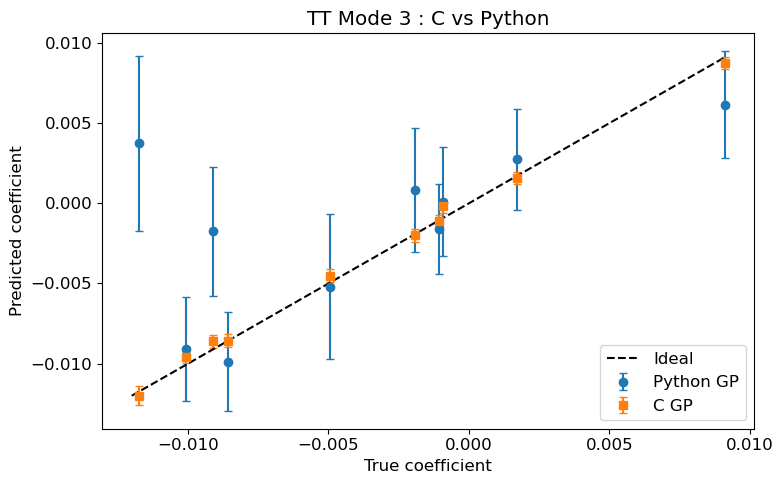

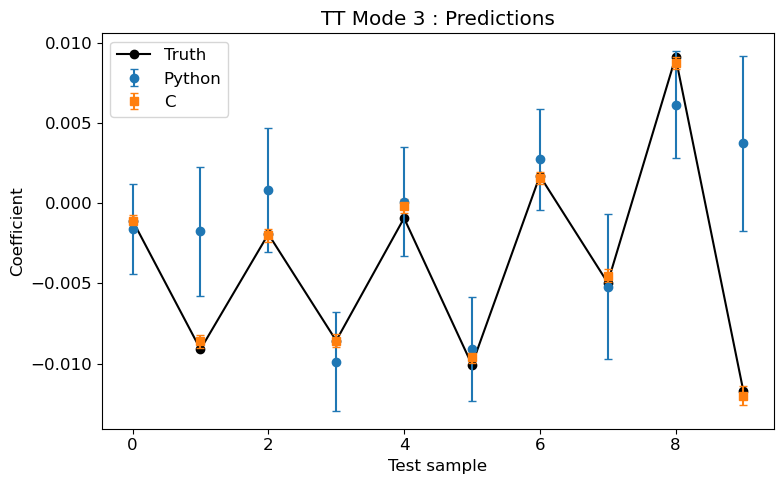

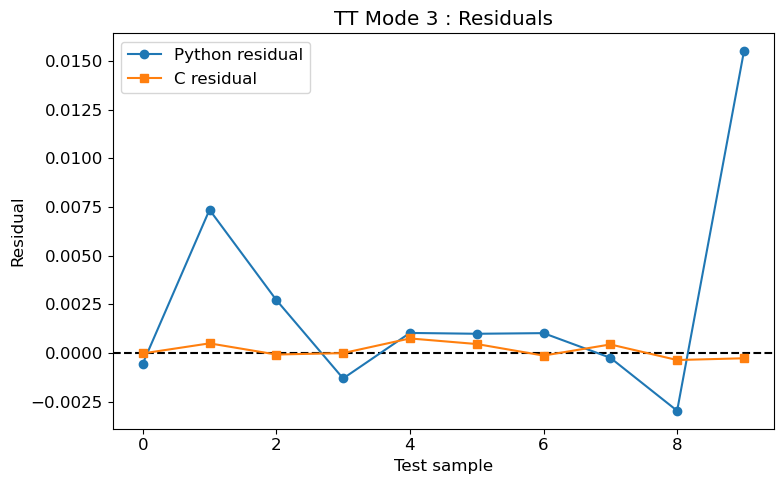

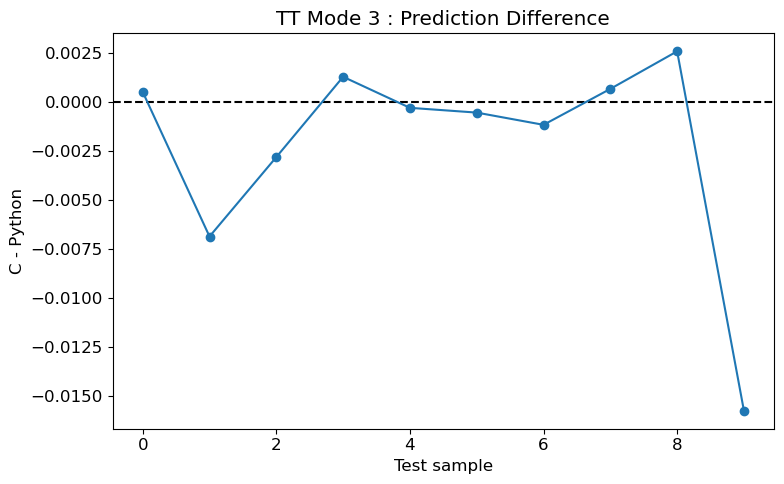

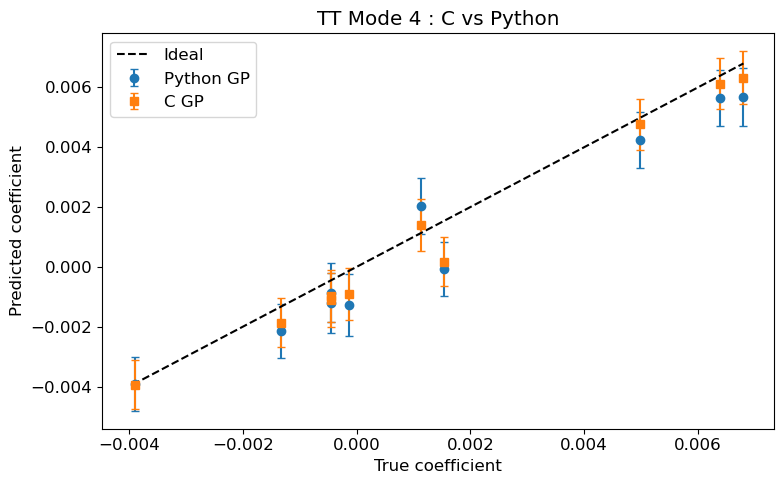

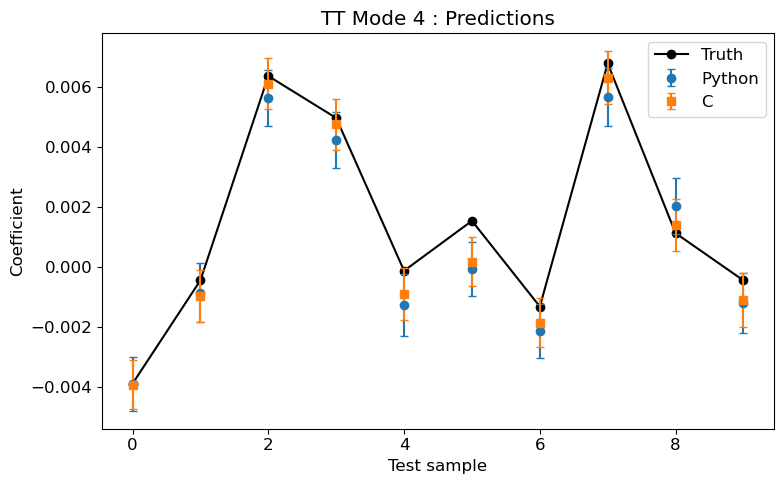

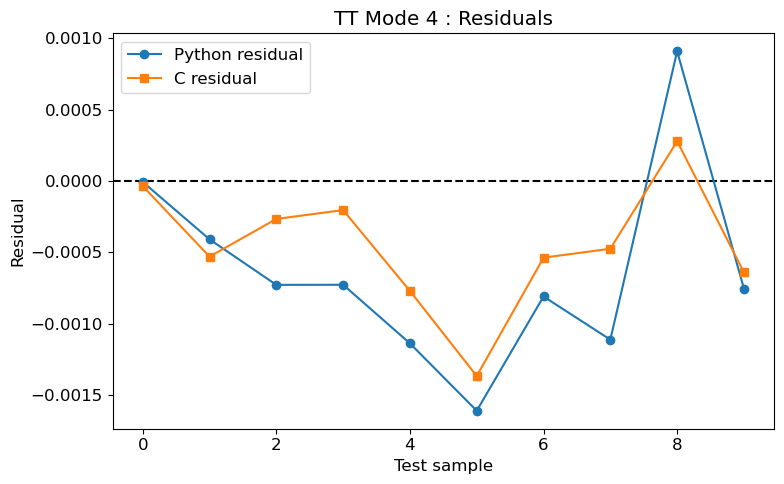

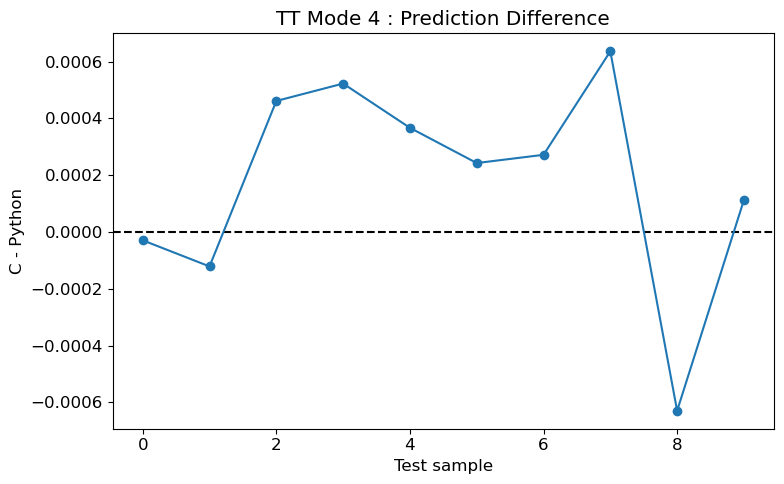

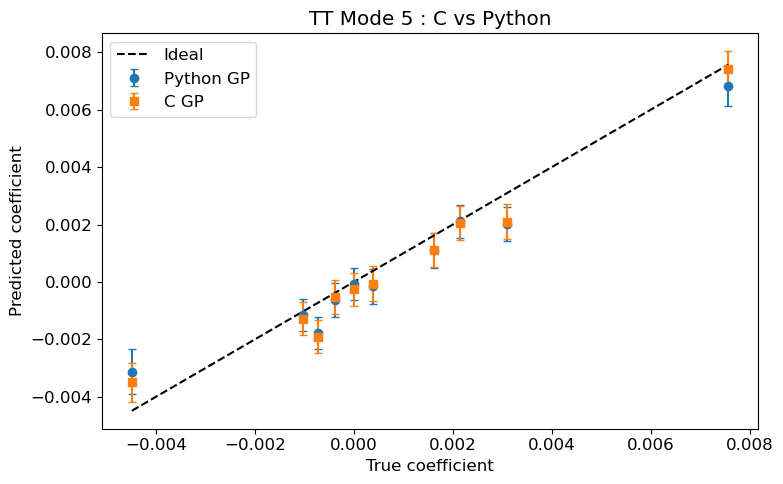

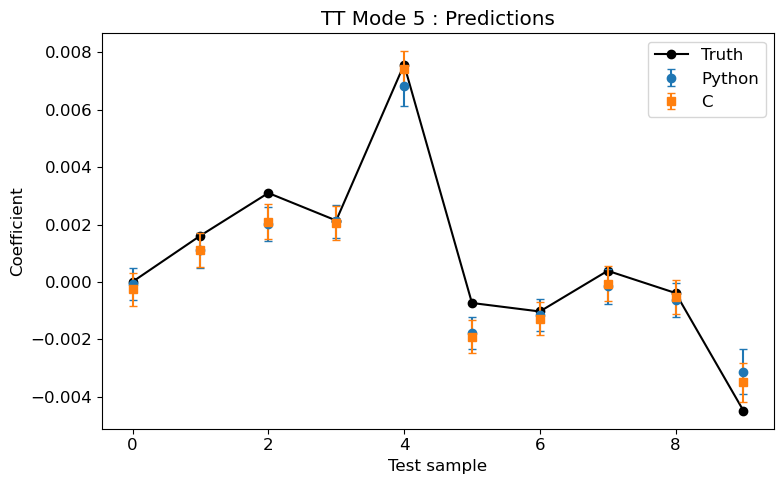

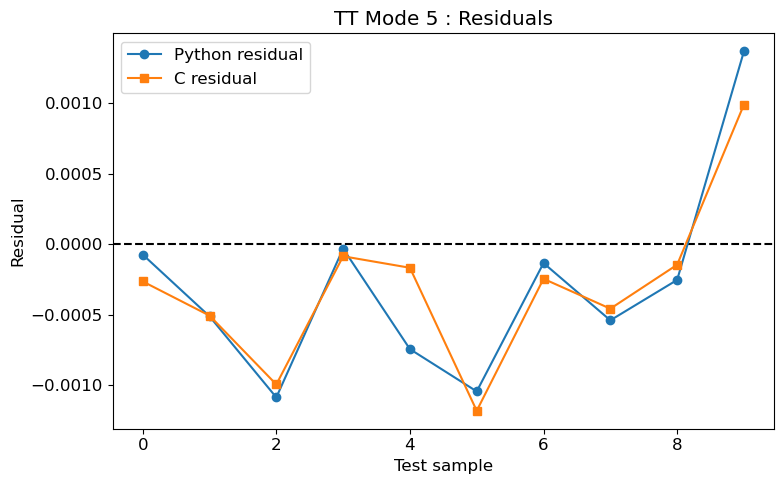

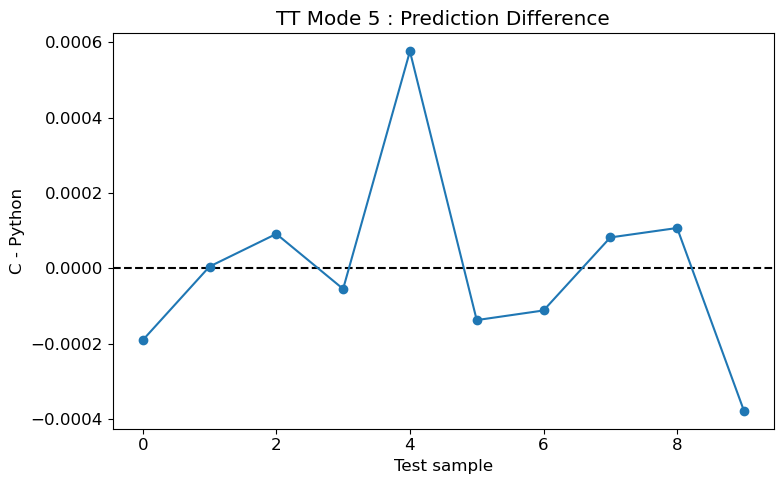

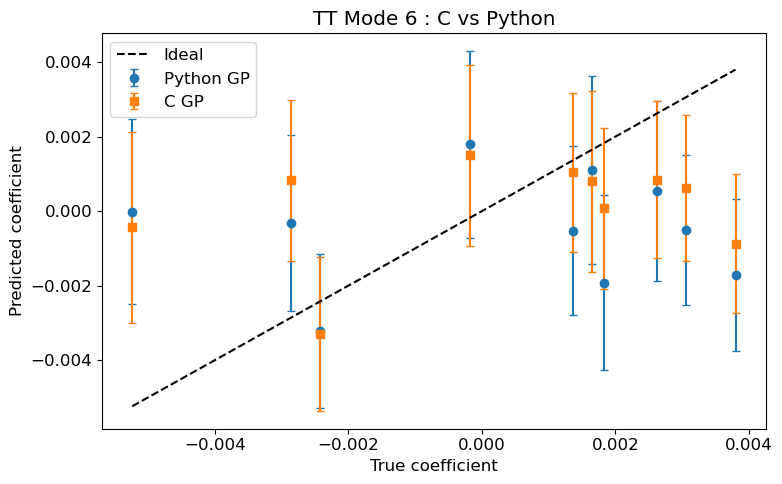

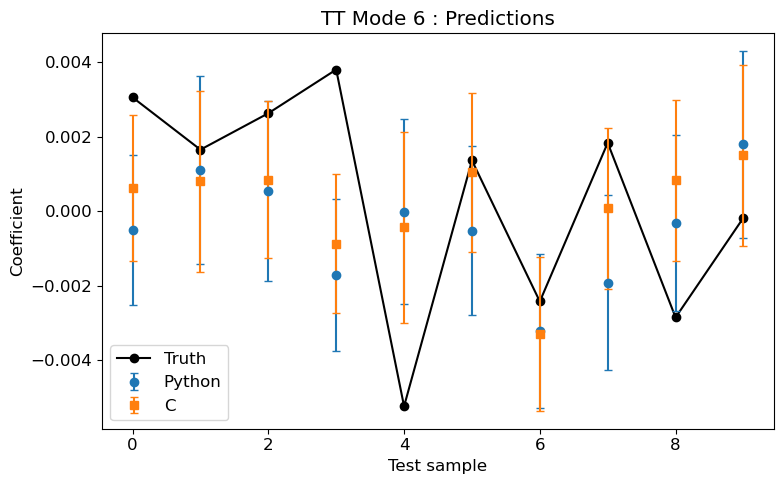

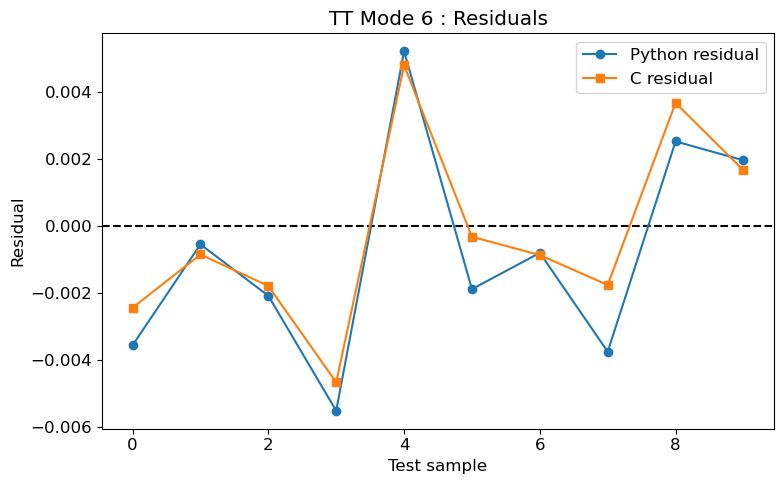

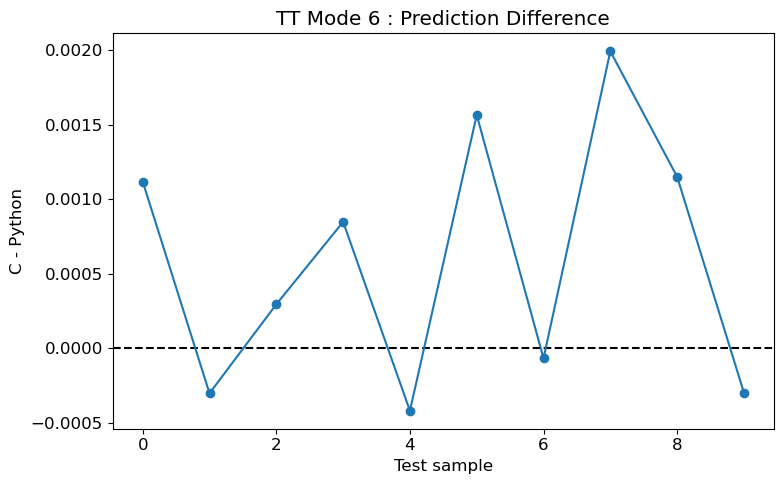

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# SETTINGS
# ============================================================

GP_DIR_C  = "cGP_outputs"
GP_DIR_PY = "pGP_outputs"

FIELD = "TT"

# ============================================================
# HELPERS
# ============================================================

def read_info(fname):

    info = {}

    with open(fname, "r") as f:

        for line in f:

            parts = line.strip().split()

            if len(parts) != 2:
                continue

            k, v = parts

            try:
                info[k] = int(v)
                continue

            except ValueError:
                pass

            try:
                info[k] = float(v)
                continue

            except ValueError:
                pass

            info[k] = v

    return info


def load_array(fname, shape=None):

    arr = np.fromfile(
        fname,
        dtype=np.float64
    )

    if shape is not None:

        shape = list(shape)

        if -1 in shape:

            idx = shape.index(-1)

            known = 1

            for s in shape:

                if s != -1:
                    known *= s

            shape[idx] = arr.size // known

        arr = arr.reshape(shape)

    return arr


# ============================================================
# LOAD INFO
# ============================================================

info_c = read_info(
    f"{GP_DIR_C}/{FIELD}/gp_info.txt"
)

info_py = read_info(
    f"{GP_DIR_PY}/{FIELD}/gp_info.txt"
)

Ntest  = info_c["Ntest"]
nmodes = info_c["nmodes"]

print("\n================================================")
print("COMPARE C vs PYTHON GP")
print("================================================")

print("Field :", FIELD)
print("Ntest :", Ntest)
print("Modes :", nmodes)

# ============================================================
# LOAD C OUTPUTS
# ============================================================

pred_mean_c = load_array(
    f"{GP_DIR_C}/{FIELD}/pred_coeff_mean.bin",
    (Ntest, nmodes)
)

pred_std_c = load_array(
    f"{GP_DIR_C}/{FIELD}/pred_coeff_std.bin",
    (Ntest, nmodes)
)

true_c = load_array(
    f"{GP_DIR_C}/{FIELD}/true_coeff_test.bin",
    (Ntest, nmodes)
)

# ============================================================
# LOAD PYTHON OUTPUTS
# ============================================================

pred_mean_py = load_array(
    f"{GP_DIR_PY}/{FIELD}/pred_coeff_mean.bin",
    (Ntest, nmodes)
)

pred_std_py = load_array(
    f"{GP_DIR_PY}/{FIELD}/pred_coeff_std.bin",
    (Ntest, nmodes)
)

true_py = load_array(
    f"{GP_DIR_PY}/{FIELD}/true_coeff_test.bin",
    (Ntest, nmodes)
)

# ============================================================
# CHECK TRUTH
# ============================================================

truth_diff = np.max(
    np.abs(true_c - true_py)
)

print("\nMax truth difference:")
print(truth_diff)

# ============================================================
# GLOBAL STYLE
# ============================================================

plt.rcParams["figure.figsize"] = (8,5)
plt.rcParams["font.size"] = 12

# ============================================================
# MODE LOOP
# ============================================================

for mode in range(nmodes):

    print("\n================================================")
    print(f"MODE {mode}")
    print("================================================")

    y_true = true_py[:, mode]

    y_c  = pred_mean_c[:, mode]
    y_py = pred_mean_py[:, mode]

    s_c  = pred_std_c[:, mode]
    s_py = pred_std_py[:, mode]

    # --------------------------------------------------------
    # DIFFERENCES
    # --------------------------------------------------------

    diff = y_c - y_py

    mae = np.mean(np.abs(diff))

    rmse = np.sqrt(
        np.mean(diff**2)
    )

    maxerr = np.max(
        np.abs(diff)
    )

    print("\nC vs Python prediction difference")

    print(f"MAE     = {mae:.6e}")
    print(f"RMSE    = {rmse:.6e}")
    print(f"MAX ERR = {maxerr:.6e}")

    # --------------------------------------------------------
    # TRUE VS PRED
    # --------------------------------------------------------

    plt.figure()

    plt.errorbar(
        y_true,
        y_py,
        yerr=s_py,
        fmt='o',
        capsize=3,
        label='Python GP'
    )

    plt.errorbar(
        y_true,
        y_c,
        yerr=s_c,
        fmt='s',
        capsize=3,
        label='C GP'
    )

    xmin = min(
        y_true.min(),
        y_py.min(),
        y_c.min()
    )

    xmax = max(
        y_true.max(),
        y_py.max(),
        y_c.max()
    )

    plt.plot(
        [xmin, xmax],
        [xmin, xmax],
        'k--',
        label='Ideal'
    )

    plt.xlabel("True coefficient")
    plt.ylabel("Predicted coefficient")

    plt.title(
        f"{FIELD} Mode {mode} : C vs Python"
    )

    plt.legend()

    plt.tight_layout()

    # --------------------------------------------------------
    # SAMPLE INDEX
    # --------------------------------------------------------

    idx = np.arange(Ntest)

    plt.figure()

    plt.plot(
        idx,
        y_true,
        'k-o',
        label='Truth'
    )

    plt.errorbar(
        idx,
        y_py,
        yerr=s_py,
        fmt='o',
        capsize=3,
        label='Python'
    )

    plt.errorbar(
        idx,
        y_c,
        yerr=s_c,
        fmt='s',
        capsize=3,
        label='C'
    )

    plt.xlabel("Test sample")
    plt.ylabel("Coefficient")

    plt.title(
        f"{FIELD} Mode {mode} : Predictions"
    )

    plt.legend()

    plt.tight_layout()

    # --------------------------------------------------------
    # RESIDUALS
    # --------------------------------------------------------

    plt.figure()

    plt.axhline(
        0.0,
        color='k',
        linestyle='--'
    )

    plt.plot(
        idx,
        y_py - y_true,
        'o-',
        label='Python residual'
    )

    plt.plot(
        idx,
        y_c - y_true,
        's-',
        label='C residual'
    )

    plt.xlabel("Test sample")
    plt.ylabel("Residual")

    plt.title(
        f"{FIELD} Mode {mode} : Residuals"
    )

    plt.legend()

    plt.tight_layout()

    # --------------------------------------------------------
    # DIRECT DIFFERENCE
    # --------------------------------------------------------

    plt.figure()

    plt.axhline(
        0.0,
        color='k',
        linestyle='--'
    )

    plt.plot(
        idx,
        diff,
        'o-'
    )

    plt.xlabel("Test sample")
    plt.ylabel("C - Python")

    plt.title(
        f"{FIELD} Mode {mode} : Prediction Difference"
    )

    plt.tight_layout()

# ============================================================
# GLOBAL STATISTICS
# ============================================================

global_diff = pred_mean_c - pred_mean_py

print("\n================================================")
print("GLOBAL DIFFERENCES")
print("================================================")

print(
    "Mean abs diff :",
    np.mean(np.abs(global_diff))
)

print(
    "RMSE diff     :",
    np.sqrt(np.mean(global_diff**2))
)

print(
    "Max diff      :",
    np.max(np.abs(global_diff))
)

# ============================================================
# SHOW
# ============================================================

plt.show()